# Terzaghi 1D Single-Layer

Demo for the 1D single layer FEM model to get settlement.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.fem import Get_terzaghi1D_FEA
from src.plotting.terzaghi_1d.plot import Get_Settlement_Plot

sns.set_theme(style="whitegrid")

H = 5.0
num = 1000
nodes = num + 1
load = 100.0
Cv = 2e-7
Mv = 5e-4
base = 2.5
T = 365 * (24 * 60 * 60)
time_steps = 1000
use_uniform_u0 = False

depth = - np.linspace(0.0, H, nodes) 
time_day = np.linspace(0.0, T / (60 * 60 * 24), time_steps)


w_w = 9.81   # kN/m³
k = Cv * Mv * w_w
print(f"Cv = {Cv:.2e} m2/s")
print(f"Mv = {Mv:.2e} m2/kN")
print(f"k  = {k:.2e} m/s ")

Cv = 2.00e-07 m2/s
Mv = 5.00e-04 m2/kN
k  = 9.81e-10 m/s 


## Settlement through time

u_hist shape:             (1000, 1001)
settlement_history shape: (1000,)
Final settlement:         0.097669 m
Total Settlement:         0.151633


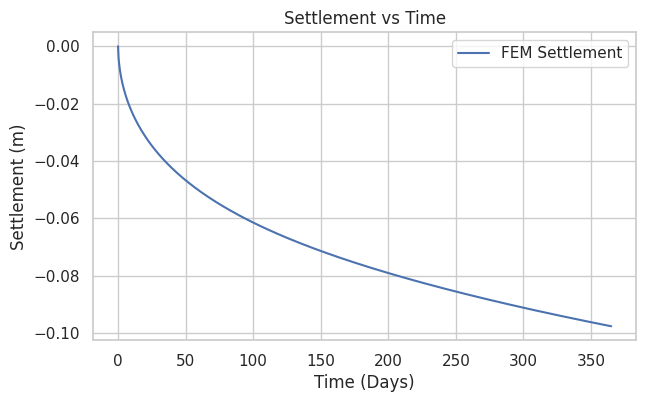

In [10]:
settlement_history, u_hist, settlement_profile = Get_terzaghi1D_FEA(H, num, load, T, time_steps, Cv, base, Mv, use_uniform_u0)

print(f"u_hist shape:             {u_hist.shape}")
print(f"settlement_history shape: {settlement_history.shape}")
print(f"Final settlement:         {settlement_history[-1]:.6f} m")
print(f"Total Settlement:         {np.sum(settlement_profile):.6f}")

fig, ax = Get_Settlement_Plot( settlement_history , time_day)

## Qaudatrue Settlement Sum

### for np.sum 

Final settlement:         0.096509 m

Total Settlement:         0.150851



### for np.trapezoid 

Final settlement:         0.097669

Total Settlement:         0.151633


## Settle3 Comparison



In [11]:
file = 'settle3_data/settle3_1d_single.xlsx'


settle3_1y = pd.read_excel(file, sheet_name="2. Stage 2 = 1 y")['Total Consolidation Settlement'].iloc[0]
settle3_1000y = pd.read_excel(file, sheet_name="3. Stage 3 = 1000 y")['Total Consolidation Settlement'].iloc[0]

# Build comparison table
results = {
    'Settle3': [settle3_1y, settle3_1000y],
    'FEM Rectangle': [0.96509, 0.15851],
    'FEM Trapezoid': [0.97669, 0.151633],
}

results = pd.DataFrame(results, index=['1 year', '1000 year'])
results


,Settle3,FEM Rectangle,FEM Trapezoid
1 year,0.098095,0.96509,0.976690
1000 year,0.151710,0.15851,0.151633


In [12]:
errors = {
    'FEM Rectangle Error': np.abs(results['FEM Rectangle']) - np.abs(results['Settle3']),
    'FEM Trapezoid Error': np.abs(results['FEM Trapezoid']) - np.abs(results['Settle3']),
}

errors = pd.DataFrame( errors, index=results.index)
errors

,FEM Rectangle Error,FEM Trapezoid Error
1 year,0.866995,0.878595
1000 year,0.006800,-0.000077
